# Esse nootebook do coolab serve para fazer o pré-processamento de dados para

#no próximo nootebok fazer a modelagem dos dados.
---
# >============================================================<
# Etapa 1. Montar o Drive e Importar o Dataset
# >============================================================<


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

# ajuste o caminho conforme onde você salvou o CSV no seu Drive
path = '/content/drive/MyDrive/Projetos/Telco-Customer-Churn.xls'
df = pd.read_csv(path)

print("Shape do dataset:", df.shape)
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape do dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes




---


# >============================================================<
# Etapa 2. Checar Desbalenceamento Da Variável Target
# >============================================================<

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


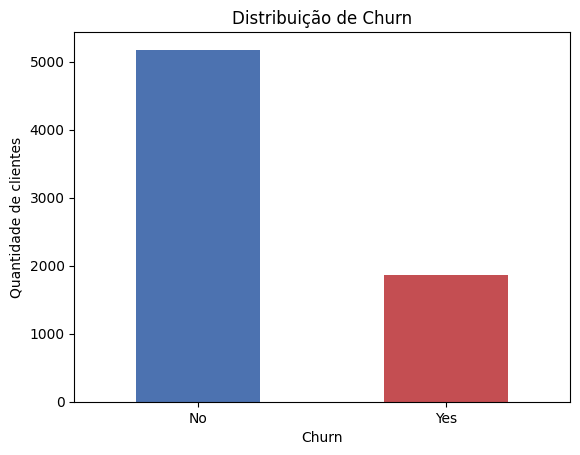

In [ ]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=0)
plt.show()


---

# >============================================================<
# Etapa 3. Diagnóstico e Tratamento Do TotalCharges
# >============================================================<

In [ ]:
print("Tipo original de TotalCharges:", df['TotalCharges'].dtype)

# identifica linhas problemáticas (strings vazias/espaços)
problematic = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"Linhas problemáticas: {len(problematic)}")
print(problematic[['customerID', 'tenure', 'TotalCharges']])

# converte para numérico (vira NaN onde não for possível converter)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# confirma a hipótese: são todos clientes com tenure == 0?
print("Tenure dos casos problemáticos:", df[df['TotalCharges'].isna()]['tenure'].unique())

# preenche com 0 (cliente novo, ainda não foi cobrado)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Tipo final de TotalCharges:", df['TotalCharges'].dtype)
print("Nulos restantes:", df['TotalCharges'].isna().sum())


Tipo original de TotalCharges: object
Linhas problemáticas: 11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             
Tenure dos casos problemáticos: [0]
Tipo final de TotalCharges: float64
Nulos restantes: 0


---


# >============================================================<
# Etapa 4. Limpeza Geral
# >============================================================<

In [ ]:
# remove identificador único (não ajuda o modelo)
df.drop('customerID', axis=1, inplace=True)

# converte target para binário
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

---


# >============================================================<
# Etapa 5. Feature Engineering
# >============================================================<

In [ ]:
# --- Quantidade de serviços contratados ---
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] not in ['No', 'No internet service', 'No phone service']:
            count += 1
    return count

df['NumServices'] = df.apply(count_services, axis=1)

# --- Ticket médio por mês de casa ---
df['AvgChargePerTenure'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# --- Cliente novo (tenure baixo é forte preditor de churn) ---
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# --- Contrato mensal (maior fator de risco historicamente) ---
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)

# --- Faixas de tenure (ajuda interpretabilidade) ---
def tenure_group(t):
    if t <= 12: return '0-1 ano'
    elif t <= 24: return '1-2 anos'
    elif t <= 48: return '2-4 anos'
    else: return '4+ anos'

df['TenureGroup'] = df['tenure'].apply(tenure_group)


---


# >============================================================<
# Etapa 6. Separar catégoricas e numéricas
# >============================================================<

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Churn')  # remove o target da lista

print("Categóricas:", categorical_cols)
print("Numéricas:", numerical_cols)


Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgChargePerTenure', 'IsNewCustomer', 'IsMonthToMonth']


---


# >============================================================<
# Etapa 7. Enconding (One-hot)
# >============================================================<

In [ ]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape final:", df_encoded.shape)
df_encoded.head()

Shape final: (7043, 38)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,NumServices,AvgChargePerTenure,IsNewCustomer,IsMonthToMonth,gender_Male,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 anos,TenureGroup_2-4 anos,TenureGroup_4+ anos
0,0,1,29.85,29.85,0,2,29.850000,1,1,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,4,55.573529,0,0,True,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,4,54.075000,1,1,True,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,4,40.905556,0,0,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,2,75.825000,1,1,False,...,False,False,False,True,False,True,False,False,False,False


---


# >============================================================<
# Etapa 8. Separar x e y, salvar com tudo já processado
# >============================================================<

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X:", X.shape, "| y:", y.shape)

df_encoded.to_csv('/content/drive/MyDrive/Projetos/processed_data.csv', index=False)
print("Dataset processado salvo com sucesso!")

X: (7043, 37) | y: (7043,)
Dataset processado salvo com sucesso!
